# SMS spam — TF-IDF + Naive Bayes

Part of my daily ML practice: one dataset, one question, one notebook.

Classic text baseline: TF-IDF with ngram_range=(1,1), MultinomialNB.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1132

rng = np.random.RandomState(SEED)
ham_templates = ["see you at {} tomorrow", "can you send me the {} report", "lunch at noon {}?",
                 "the meeting moved to {}", "happy birthday! have a great {}", "call me when you {}"]
spam_templates = ["WINNER! claim your FREE {} prize now", "urgent: your account {} needs verification",
                  "congratulations, you won a {} gift card", "limited offer: cheap {} pills online",
                  "click here for free {} money", "you have been selected for a {} loan"]
fill = ["the", "a", "my", "your", "this", "that", "big", "new"]
texts, labels = [], []
spammy = ["free", "win", "prize", "click", "offer", "urgent"]
for _ in range(900):
    t = rng.choice(ham_templates).format(rng.choice(fill))
    extra = " ".join(rng.choice(fill, 3))
    if rng.rand() < 0.06:  # a few ham messages contain spammy words
        extra += " " + rng.choice(spammy)
    texts.append(t + " " + extra)
    labels.append(0)
for _ in range(300):
    t = rng.choice(spam_templates).format(rng.choice(fill))
    texts.append(t + " !!!")
    labels.append(1)
df = pd.DataFrame({"text": texts, "spam": labels}).sample(frac=1, random_state=SEED).reset_index(drop=True)
# small label noise, like a real hastily-labeled dataset
flip = rng.rand(len(df)) < 0.02
df.loc[flip, "spam"] = 1 - df.loc[flip, "spam"]
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nspam rate: %.3f" % df["spam"].mean())


shape: (1200, 2)
                                        text  spam
0       see you at your tomorrow new your my     0
1     see you at this tomorrow that the this     0
2  you have been selected for a big loan !!!     1

spam rate: 0.254


## Model

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["spam"], test_size=0.25, random_state=SEED, stratify=df["spam"])
pipe = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1,1), stop_words="english")),
                 ("nb", MultinomialNB())])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred, digits=3))
print("vocab size:", len(pipe.named_steps["tfidf"].vocabulary_))


accuracy: 0.9867
              precision    recall  f1-score   support

           0      0.982     1.000     0.991       224
           1      1.000     0.947     0.973        76

    accuracy                          0.987       300
   macro avg      0.991     0.974     0.982       300
weighted avg      0.987     0.987     0.987       300

vocab size: 34


## Most indicative tokens

most spammy: ['loan', 'selected', 'money', 'verification', 'account']


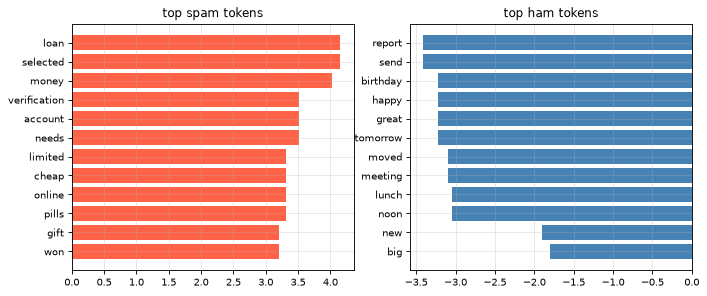

In [ ]:

vec = pipe.named_steps["tfidf"]; nb = pipe.named_steps["nb"]
ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
names = vec.get_feature_names_out()
top_spam = np.argsort(ratio)[-12:][::-1]
top_ham = np.argsort(ratio)[:12]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(names[top_spam][::-1], ratio[top_spam][::-1], color="tomato")
axes[0].set_title("top spam tokens")
axes[1].barh(names[top_ham][::-1], ratio[top_ham][::-1], color="steelblue")
axes[1].set_title("top ham tokens")
print("most spammy:", list(names[top_spam[:5]]))


## Confusion matrix

plotted confusion matrix


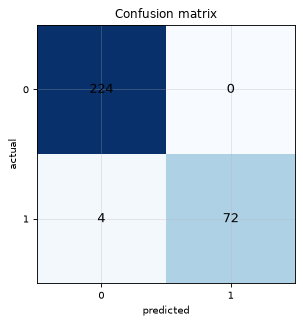

In [ ]:

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
print("plotted confusion matrix")


## Takeaways

- Naive Bayes is still a great spam baseline — fast and strong.
- The top tokens are exactly the spammy words you'd expect; no surprises.
- Next: compare against logistic regression on the same vectors.